# Project 1: Deep Learning-Based Sentiment Analysis on Twitter Airline Reviews
## Course: Applied Natural Language Processing
### Name: Md Anwar Hossain
### Date: 22 March 2026

This project was completed as part of my Aplied Natural Language Processing course at Victoria University. The Project instructions are given below:

## **Project Aim**

This project requires students to design, implement, and evaluate multiple deep learning architectures 
to perform multi-class sentiment classification on real-world Twitter data.

**Students must:**

1.  Perform advanced text preprocessing

2.  Train custom Word2Vec embeddings 

3.  Implement RNN, GRU, and LSTM models

4.  Compare deep learning architectures 

5.  Critically evaluate model performance
    
6.  Provide business insights and ethical considerations 

## **Learning Outcomes Alignment**

This project addresses:

•  LO1: Critically review NLP applications

•  LO2: Analyse NLP architecture components

•  LO3: Apply knowledge discovery processes 

•  LO4: Evaluate NLP techniques 

•  LO5: Design NLP solutions with ethical awareness

## **Dataset (Kaggle)** 

https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment/data

Twitter US Airline Sentiment Dataset Available on Kaggle: 
“Twitter US Airline Sentiment”

•  Labeled as:

o  Positive

o  Neutral

o  Negative 

•  Additional metadata:

o  Airline name

o  Confidence score

o  Reason for negative sentiment

o  Tweet location

o  Timestamp

**Technical Requirements**

## 1. Data Preparation 

**Students must:**

Mandatory Steps:

•  Convert text to lowercase

•  Remove URLs

•  Remove mentions (@username) 

•  Remove hashtags (or experiment retaining them) 

•  Remove special characters

•  Tokenization 

•  Padding sequences 

•  Train/Test/Validation split (70/20/10)

**Advance Requirement:**

Students must compare:

•  With hashtag removal

•  Without hashtag removal

**And discuss performance impact.**

Expected output: 

•  Vocabulary size

•  Average tweet length

•  Class distribution visualization

## **2. Word Embeddings**
**Students must:**

•  Train Word2Vec 

•  Choose embedding dimension (e.g., 100 or 200) 

•  Build embedding matrix

•  Handle OOV words

•  Visualize embeddings using t-SNE (optional bonus)

**Students must justify:**

•  Embedding size 

•  Window size 

•  Minimum word frequency 

## **3. Deep Learning Architectures** 

Students must implement and compare:

Model 1: Simple RNN

Embedding → RNN → Dense → Softmax

Model 2: GRU

Embedding → GRU → Dropout → Dense → Softmax

Model 3: LSTM

Embedding → LSTM → Dropout → Dense → Softmax

Students must:

•  Use EarlyStopping 

•  Apply Dropout 

•  Hyperparameter tuning 

•  Class weight handling (if imbalance exists) 

**Students must provide architecture diagrams.**

## **4. Model Evaluation** 

Students must evaluate using: 

•  Accuracy

•  Precision (macro & weighted) 

•  Recall

•  F1-score

•  Confusion matrix

•  Training vs validation loss curves 

**They must compare:**

**Model  Accuracy  F1  Overfitting  Training Time**

**Critical analysis required:**

•  Which architecture handles noisy data best?

•  Why LSTM might outperform RNN? 

•  Does GRU train faster?


# Code Implementation

# Aims 1-6: Preprocessing, Word2Vec, Deep RNNs (RNN/GRU/LSTM), Evaluation & Insights  
**Dataset:** Twitter US Airline Sentiment (`Tweets.csv`)

This end‑to‑end notebook implements:

**Aim 1 – Advanced Text Preprocessing (Mandatory & Advanced requirements)**  
Lowercase → remove **URLs** → remove **@mentions** → hashtag handling (two variants) → remove **special chars** → **tokenization** → **padding** → **stratified 70/20/10** split.  
Compare **with** vs **without** hashtag removal and report: **vocab size**, **avg tweet length**, and a **class distribution** chart.

**Aim 2 – Word Embeddings**  
Train **Word2Vec** (gensim), choose **embedding dim** (default 200), build **embedding matrix**, handle **OOV**, optional **t‑SNE** visualization.

**Aim 3 – Deep Learning Architectures**  
Implement and compare:  
- **Model 1: Simple RNN** — Embedding → SimpleRNN → Dense → Softmax  
- **Model 2: GRU** — Embedding → GRU → **Dropout** → Dense → Softmax  
- **Model 3: LSTM** — Embedding → LSTM → **Dropout** → Dense → Softmax  
With **EarlyStopping**, **Dropout**, lightweight **hyperparameter tuning**, and **class‑weighting** for imbalance.

**Aim 4 – Compare Deep Learning Architecture: Model Evaluation**  
Compute **Accuracy**, **Precision** (macro & weighted), **Recall**, **F1**; **Confusion matrix**; **train vs val loss curves**; and summarize **Model, Accuracy, F1, Overfitting, Training Time**.

**Aim 5 – Critical Evaluation**  
Discussion of noise‑robustness, why LSTM may outperform RNN (vanishing gradients), and whether GRU trains faster.

**Aim 6 – Business Insights & Ethical Considerations**  
Actionable insights from misclassifications/trends; fairness, representativeness, data privacy, and responsible use.

> **References (for parameters & methods)**:  
> • Word2Vec (Mikolov et al., 2013)  
> • Keras/TensorFlow RNN layers (SimpleRNN/GRU/LSTM) and EarlyStopping  
> • scikit‑learn metrics (classification report, confusion matrix)  
> • t‑SNE (van der Maaten & Hinton, 2008)

## 0. Setup, load dataset, and reproducibility


In [1]:
# Standard library & scientific stack
import os, re, json, math, random, time, warnings
from collections import Counter, defaultdict
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Dataset expectations
DATA_FILE = 'E:/Project 1/Tweets.csv'              # file must be in the same folder
TEXT_COL = 'text'                     # tweet text column
LABEL_COL = 'airline_sentiment'       # sentiment label column

# Sanity checks
assert os.path.exists(DATA_FILE), f"Expected {DATA_FILE} next to this notebook."

twitter_df = pd.read_csv(DATA_FILE)
# Fixed: Changed 'df' to 'twitter_df' to match the variable name used when loading the CSV
assert TEXT_COL in twitter_df.columns and LABEL_COL in twitter_df.columns, f"Missing columns. Found: {list(twitter_df.columns)}"


## 1. Exploratory Data Analysis (EDA)

### 1.1 Show an overview of the dataset

In [2]:
twitter_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

### 1.2 Show an overview of top rows of each column

In [3]:
twitter_df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


### 1.3 Get required columns for the analyses

In [4]:
# Get required columns for the analyses
df = pd.read_csv(DATA_FILE)[[TEXT_COL, LABEL_COL]].dropna().reset_index(drop=True)
df[LABEL_COL] = df[LABEL_COL].astype(str)
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (14640, 2)


,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


### 1.4 See class distribution
#### Plot class counts and save for the report
#### See Tweets length (characters)
#### See example tweets

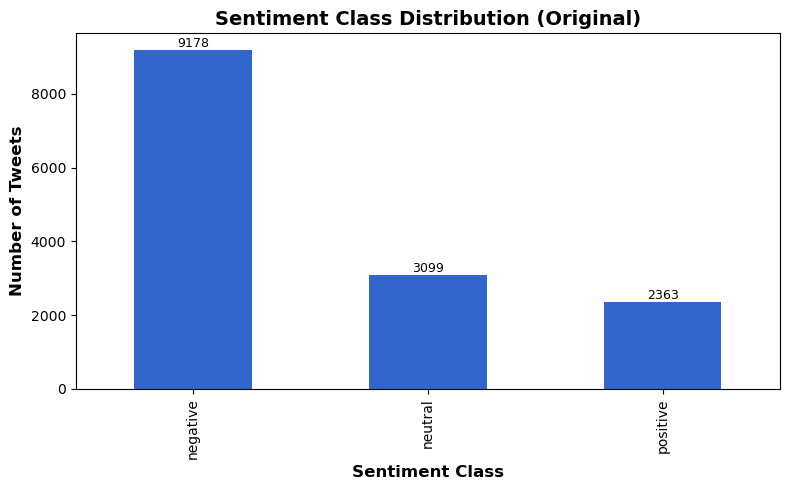

[Saved] E:/Project 1/class_distribution.png


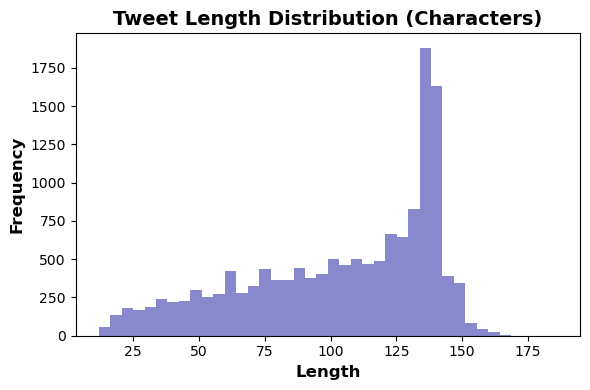

Sample negative tweets:
@VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse@VirginAmerica and it's a really big bad thing about it@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.
it's really the only bad thing about flying VA
Sample neutral tweets:
@VirginAmerica What @dhepburn said.@VirginAmerica I didn't today... Must mean I need to take another trip!@VirginAmerica Really missed a prime opportunity for Men Without Hats parody, there. https://t.co/mWpG7grEZP
Sample positive tweets:
@VirginAmerica plus you've added commercials to the experience... tacky.@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)@virginamerica Well, I didn't…but NOW I DO! :-D


In [5]:
# See class distribution
# Plot class counts and save for the report

def plot_class_distribution(df: pd.DataFrame, label_col: str, title: str, out_path: str) -> str:
    counts = df[label_col].value_counts().sort_index()
    plt.figure(figsize=(8,5))
    ax = counts.plot(kind='bar', color='#3366cc')
    plt.title("Sentiment Class Distribution (Original)", fontdict={'fontsize': 14, 'fontweight': 'bold'})
    plt.xlabel('Sentiment Class', fontdict={'fontsize': 12, 'fontweight': 'bold'})
    plt.ylabel('Number of Tweets', fontdict={'fontsize': 12, 'fontweight': 'bold'})
    for i, v in enumerate(counts.values):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    return out_path

output_directory = "E:/Project 1/"  # Specify your directory path here
plot_path = plot_class_distribution(
    df, 
    LABEL_COL, 
    'Class distribution (original)', 
    f"{output_directory}class_distribution.png"  # Full path with directory
)
print('[Saved]', plot_path)

# Tweet length (characters)
lengths = df[TEXT_COL].astype(str).apply(len)
plt.figure(figsize=(6,4))
plt.hist(lengths, bins=40, color='#8888cc')
plt.title('Tweet Length Distribution (Characters)', fontdict={'fontsize': 14, 'fontweight': 'bold'})
plt.xlabel('Length', fontdict={'fontsize': 12, 'fontweight': 'bold'}) 
plt.ylabel('Frequency', fontdict={'fontsize': 12, 'fontweight': 'bold'})
plt.tight_layout()
plt.savefig('E:/Project 1/tweet_length_hist.png', dpi=150)
plt.show()

# Sample tweets
for cls in sorted(df[LABEL_COL].unique()):
    print(f"Sample {cls} tweets:")
    print(''.join(df[df[LABEL_COL]==cls][TEXT_COL].head(3).tolist()))


## 2. Advanced Text Preprocessing — mandatory steps with explicit regexes (Aim 1)
**Order:** **lowercase → remove URLs → remove @mentions → hashtag handling → remove special characters → normalize whitespace → tokenization**.  

We run **two variants** to satisfy the advanced requirement:
- **Variant A**: *With* hashtag removal (remove entire `#token`).
- **Variant B**: *Without* hashtag removal (drop only `#`, keep the word).

**Why custom `SimpleTokenizer`?** To explicitly reserve index 0 for padding and index 1 for `<OOV>`, and keep logic transparent for the embedding matrix.

**Regex patterns:**
- `URL_PATTERN = (https?://\S+|www\.\S+)` removes links.  
- `MENTION_PATTERN = @\w+` removes mentions.  
- `HASHTAG_TOKEN_PATTERN = #\w+` removes the entire hashtag token (Variant A).  
- `HASHTAG_HASH_ONLY_PATTERN = #` drops only the `#` but keeps the word (Variant B).  
- `NON_ALNUM_SPACE_PATTERN = [^a-z0-9\s]` keeps letters/digits/spaces only.


In [6]:

# Regex patterns
URL_PATTERN = re.compile(r'(https?://\S+|www\.\S+)')
MENTION_PATTERN = re.compile(r'@\w+')
HASHTAG_TOKEN_PATTERN = re.compile(r'#\w+')
HASHTAG_HASH_ONLY_PATTERN = re.compile(r'#')
NON_ALNUM_SPACE_PATTERN = re.compile(r'[^a-z0-9\s]')


def clean_text(s: str, remove_hashtags: bool = True) -> str:
    # Apply the mandatory steps in order
    if not isinstance(s, str):
        s = str(s)
    s = s.lower()                                # 1) lowercase
    s = URL_PATTERN.sub(' ', s)                  # 2) remove urls
    s = MENTION_PATTERN.sub(' ', s)              # 3) remove @mentions
    if remove_hashtags:
        s = HASHTAG_TOKEN_PATTERN.sub(' ', s)    # 4A) remove entire #token
    else:
        s = HASHTAG_HASH_ONLY_PATTERN.sub('', s) # 4B) keep word, drop only '#'
    s = NON_ALNUM_SPACE_PATTERN.sub(' ', s)      # 5) remove special chars
    s = re.sub(r'\s+', ' ', s).strip()          # 6) normalize whitespace
    return s


class SimpleTokenizer:
    # Minimal transparent tokenizer: keeps explicit <OOV> at id 1 and padding at id 0
    def __init__(self, oov_token: str = '<OOV>'):
        self.oov_token = oov_token
        self.word_index: Dict[str, int] = {}
        self.index_word: Dict[int, str] = {}
        self.fitted = False

    def fit_on_texts(self, texts: List[str]):
        counter = Counter()
        for t in texts:
            counter.update(t.split())
        idx = 1  # 0 reserved for padding
        self.word_index = {self.oov_token: idx}; idx += 1
        for w, c in counter.items():
            if not w or w == self.oov_token:
                continue
            if w not in self.word_index:
                self.word_index[w] = idx; idx += 1
        self.index_word = {i:w for w,i in self.word_index.items()}
        self.fitted = True

    def texts_to_sequences(self, texts: List[str]) -> List[List[int]]:
        assert self.fitted, 'Tokenizer must be fitted before use.'
        oov_id = self.word_index[self.oov_token]
        seqs = []
        for t in texts:
            seqs.append([self.word_index.get(tok, oov_id) for tok in t.split()])
        return seqs


def pad_sequences(seqs: List[List[int]], maxlen: int, padding: str = 'post', truncating: str = 'post') -> np.ndarray:
    # Pad or truncate to fixed length using 0 as the pad value
    arr = np.zeros((len(seqs), maxlen), dtype=np.int32)
    for i, seq in enumerate(seqs):
        if len(seq) == 0:
            continue
        if len(seq) <= maxlen:
            if padding == 'post':
                arr[i, :len(seq)] = seq
            else:
                arr[i, -len(seq):] = seq
        else:
            if truncating == 'post':
                arr[i, :] = seq[:maxlen]
            else:
                arr[i, :] = seq[-maxlen:]
    return arr


def stratified_split_70_20_10(labels: List[str], seed: int = 42):
    # Manual stratified split without sklearn
    rng = random.Random(seed)
    by_class: Dict[str, List[int]] = defaultdict(list)
    for idx, y in enumerate(labels):
        by_class[y].append(idx)
    train_idx, val_idx, test_idx = [], [], []
    for cls, idxs in by_class.items():
        rng.shuffle(idxs)
        n = len(idxs)
        n_train = int(round(0.70 * n))
        n_val = int(round(0.20 * n))
        n_test = n - n_train - n_val
        if n_test < 0:
            n_test = 0
            n_val = n - n_train
        train_idx.extend(idxs[:n_train])
        val_idx.extend(idxs[n_train:n_train+n_val])
        test_idx.extend(idxs[n_train+n_val:])
    rng.shuffle(train_idx); rng.shuffle(val_idx); rng.shuffle(test_idx)
    return train_idx, val_idx, test_idx


def run_variant_pipeline(df_input: pd.DataFrame, remove_hashtags: bool, variant_name: str, pad_percentile: float = 95.0):
    # Execute Aim-1 pipeline for a specific hashtag policy
    dfv = df_input.copy()
    dfv['clean_text'] = dfv[TEXT_COL].apply(lambda s: clean_text(s, remove_hashtags=remove_hashtags))

    lengths_all = [len(x.split()) for x in dfv['clean_text']]
    avg_len_all = float(np.mean(lengths_all)) if lengths_all else 0.0

    labels = dfv[LABEL_COL].tolist()
    train_idx, val_idx, test_idx = stratified_split_70_20_10(labels, seed=RANDOM_SEED)
    train_df = dfv.iloc[train_idx].reset_index(drop=True)
    val_df   = dfv.iloc[val_idx].reset_index(drop=True)
    test_df  = dfv.iloc[test_idx].reset_index(drop=True)

    tok = SimpleTokenizer(oov_token='<OOV>')
    tok.fit_on_texts(train_df['clean_text'].tolist())

    seq_train = tok.texts_to_sequences(train_df['clean_text'].tolist())
    seq_val   = tok.texts_to_sequences(val_df['clean_text'].tolist())
    seq_test  = tok.texts_to_sequences(test_df['clean_text'].tolist())

    train_lengths = [len(s) for s in seq_train]
    pad_len = int(math.ceil(np.percentile(train_lengths, pad_percentile))) if train_lengths else 1
    pad_len = max(1, pad_len)

    x_train = pad_sequences(seq_train, maxlen=pad_len, padding='post', truncating='post')
    x_val   = pad_sequences(seq_val,   maxlen=pad_len, padding='post', truncating='post')
    x_test  = pad_sequences(seq_test,  maxlen=pad_len, padding='post', truncating='post')

    metrics = {
        'variant': variant_name,
        'vocab_size': len(tok.word_index) + 1,
        'avg_tweet_length_tokens': avg_len_all,
        'pad_max_len': pad_len,
        'train_size': len(train_df), 'val_size': len(val_df), 'test_size': len(test_df)
    }

    return {
        'variant': variant_name,
        'df': dfv,
        'train_df': train_df, 'val_df': val_df, 'test_df': test_df,
        'tokenizer': tok,
        'x_train': x_train, 'x_val': x_val, 'x_test': x_test,
        'metrics': metrics
    }


## 3. Run both variants (A: remove hashtags; B: keep words) and report


In [7]:

res_with    = run_variant_pipeline(df, remove_hashtags=True,  variant_name='with_hashtag_removal')
res_without = run_variant_pipeline(df, remove_hashtags=False, variant_name='without_hashtag_removal')

rows = [res_with['metrics'], res_without['metrics']]
metrics_df = pd.DataFrame(rows)[['variant','vocab_size','avg_tweet_length_tokens','pad_max_len','train_size','val_size','test_size']]
metrics_df


,variant,vocab_size,avg_tweet_length_tokens,pad_max_len,train_size,val_size,test_size
0,with_hashtag_removal,9732,16.657514,27,10248,2929,1463
1,without_hashtag_removal,10842,16.894809,27,10248,2929,1463


In [8]:

# Save and print deltas (without - with)
metrics_df.to_csv('variant_metrics.csv', index=False)
print('[Saved] variant_metrics.csv')

delta_vocab = rows[1]['vocab_size'] - rows[0]['vocab_size']
delta_len   = rows[1]['avg_tweet_length_tokens'] - rows[0]['avg_tweet_length_tokens']
print(f"Delta vocab size (without - with): {delta_vocab:+d}")
print(f"Delta avg length (tokens) (without - with): {delta_len:+.2f}")


[Saved] variant_metrics.csv
Delta vocab size (without - with): +1110
Delta avg length (tokens) (without - with): +0.24


## 4. Train custom Word2Vec Embeddings (Aim 2) — goals & outputs
- Train Word2Vec on Variant B train tokens.  
- Build an embedding matrix aligned to tokenizer ids: row 0 = padding; known words copy vectors; OOV get small random vectors.  
- Optional: visualize embeddings with t-SNE (frequent & non-frequent words).
  
We use **Variant B** (*without* hashtag removal) to preserve topical markers.
- **Embedding size** = 200 (commonly 100–300 in Word2Vec literature).  
- **Window** = 5 (local context for tweets).  
- **min_count** = 2 (trims singletons/typos).  

> See Word2Vec (Mikolov et al., 2013) and Gensim docs/tutorial for parameter meanings and trade‑offs.



In [9]:

# Prepare training tokens for Word2Vec
train_tokens = res_without['train_df']['clean_text'].apply(lambda s: s.split()).tolist()

# Try to import gensim
try:
    from gensim.models import Word2Vec
    HAS_GENSIM = True
except Exception:
    HAS_GENSIM = False
    print('Gensim not installed. Install with `pip install gensim`.')

# Hyperparameters with brief justification
EMBEDDING_DIM = 200   # typical 100-300
WINDOW_SIZE   = 5     # local context
MIN_COUNT     = 2     # trim singletons
EPOCHS        = 10
SG_MODEL      = 1     # skip-gram
NEGATIVE      = 10

if HAS_GENSIM:
    w2v = Word2Vec(
        sentences=train_tokens,
        vector_size=EMBEDDING_DIM,
        window=WINDOW_SIZE,
        min_count=MIN_COUNT,
        sg=SG_MODEL,
        negative=NEGATIVE,
        workers=4,
        epochs=EPOCHS,
        seed=RANDOM_SEED
    )
    print('Word2Vec vocab size:', len(w2v.wv))
else:
    w2v = None


Word2Vec vocab size: 5170


## 5. Build embedding matrix & handle OOV


In [10]:

variant_tok = res_without['tokenizer']

# Build embedding matrix: row i -> vector for token id i

def build_embedding_matrix(tokenizer, w2v_model, embedding_dim: int, seed: int = 42):
    vocab_size = len(tokenizer.word_index) + 1
    emb = np.zeros((vocab_size, embedding_dim), dtype=np.float32)
    rng = np.random.default_rng(seed)
    known, oov = 0, 0
    for word, idx in tokenizer.word_index.items():
        if idx == 0:
            continue  # keep padding zeros
        if (w2v_model is not None) and (word in w2v_model.wv):
            emb[idx] = w2v_model.wv[word]
            known += 1
        else:
            emb[idx] = rng.normal(0.0, 0.05, size=(embedding_dim,))
            oov += 1
    return emb, known, oov

embedding_matrix, known_cnt, oov_cnt = build_embedding_matrix(variant_tok, w2v, EMBEDDING_DIM)
print('Embedding matrix shape:', embedding_matrix.shape)
print('Coverage: known =', known_cnt, '| OOV =', oov_cnt, '| OOV rate = {:.2%}'.format(oov_cnt/(known_cnt+oov_cnt)))


Embedding matrix shape: (10842, 200)
Coverage: known = 5170 | OOV = 5671 | OOV rate = 52.31%


### 5.1 Optional: quick qualitative neighbors (sanity check)


In [11]:

if w2v is not None:
    probes = ['delay','delayed','flight','service','cancelled','baggage','gate','late']
    for p in probes:
        if p in w2v.wv.key_to_index:
            print(f"Most similar to '{p}':", w2v.wv.most_similar(p, topn=5))
        else:
            print(f"'{p}' not in Word2Vec vocabulary.")


Most similar to 'delay': [('layover', 0.7333220839500427), ('delays', 0.6953215003013611), ('reasons', 0.6908490061759949), ('mechanical', 0.6905718445777893), ('buffalo', 0.6893782019615173)]
Most similar to 'delayed': [('buffalo', 0.7023828625679016), ('aspen', 0.697327733039856), ('causing', 0.6927329897880554), ('wedding', 0.6821739077568054), ('phil', 0.6818834543228149)]
Most similar to 'flight': [('ind', 0.7192320227622986), ('jax', 0.7162526249885559), ('woo', 0.7094172239303589), ('flt', 0.7077358365058899), ('previously', 0.7064532041549683)]
Most similar to 'service': [('svc', 0.7000893950462341), ('support', 0.6636316180229187), ('relations', 0.6632502675056458), ('cs', 0.6562668085098267), ('customer', 0.6544876098632812)]
Most similar to 'cancelled': [('rescheduled', 0.7240146398544312), ('flighted', 0.7007995247840881), ('resched', 0.6926000714302063), ('flightled', 0.6923243999481201), ('notification', 0.6900060176849365)]
Most similar to 'baggage': [('claim', 0.7286679

## 6. t-SNE: frequent **and** non-frequent words — what to look for
- Frequent words: expect tighter clusters around themes (service, delays, etc.).  
- Non-frequent: more scatter; any coherent mini-clusters suggest generalization from context.


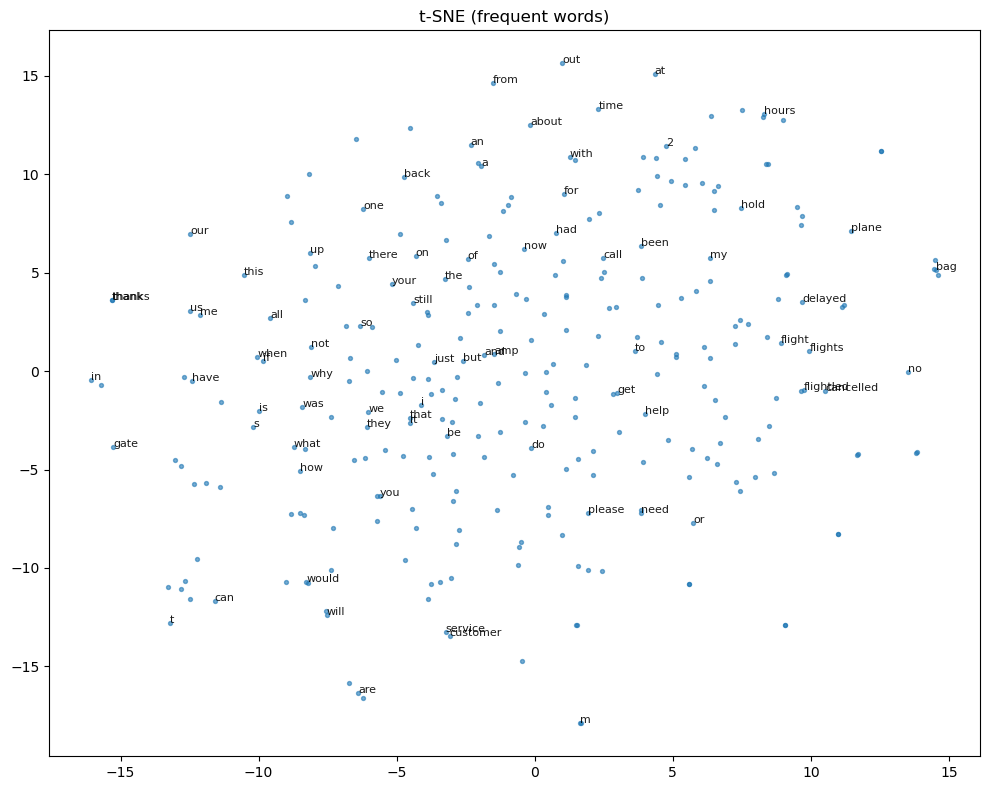

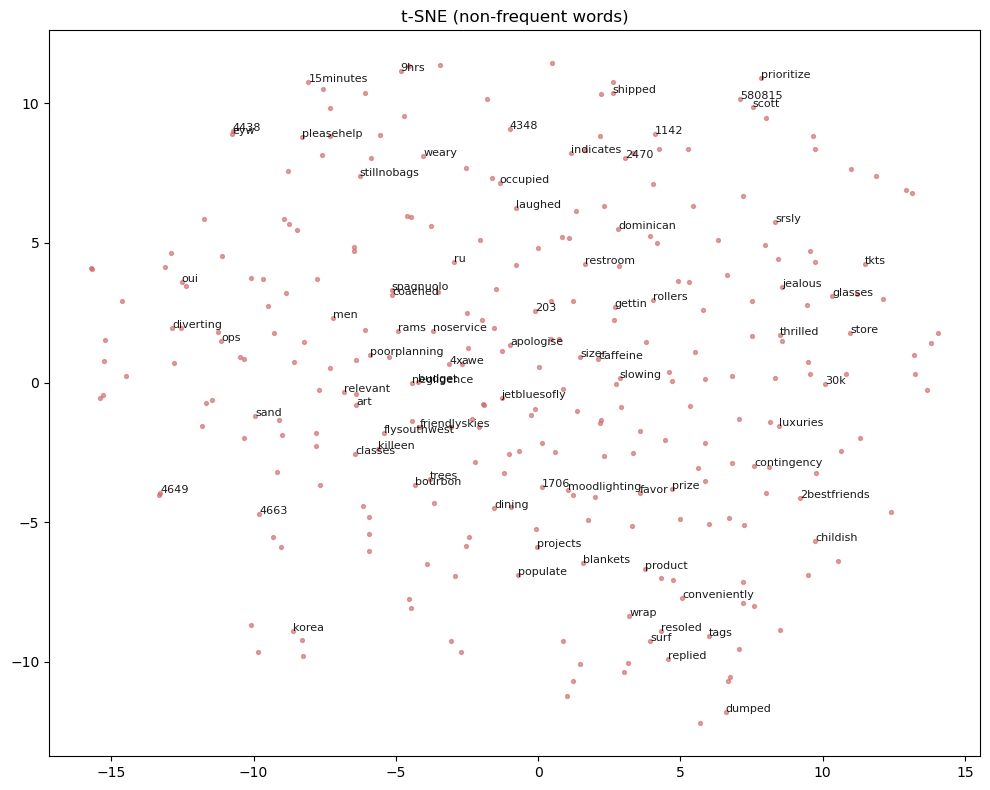

In [12]:

# t-SNE projections; saved to disk
try:
    from sklearn.manifold import TSNE
    HAS_SK = True
except Exception:
    HAS_SK = False
    print('scikit-learn not installed; skip t-SNE. Install with `pip install scikit-learn`.')

if (w2v is not None) and HAS_SK:
    freq = Counter([t for toks in train_tokens for t in toks])

    # Frequent subset (top-N)
    frequent = [w for w,_ in freq.most_common(1000) if w in w2v.wv.key_to_index]
    words_f = frequent[:300] if len(frequent) > 300 else frequent
    if len(words_f) >= 2:
        Xf = np.stack([w2v.wv[w] for w in words_f])
        X2f = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, init='pca', learning_rate='auto').fit_transform(Xf)
        plt.figure(figsize=(10,8))
        plt.scatter(X2f[:,0], X2f[:,1], s=8, alpha=0.6)
        for i, w in enumerate(words_f[:80]):
            plt.annotate(w, (X2f[i,0], X2f[i,1]), fontsize=8, alpha=0.9)
        plt.title('t-SNE (frequent words)')
        plt.tight_layout(); plt.savefig('tsne_frequent.png', dpi=150); plt.show()

    # Non-frequent subset (bottom quantile but >= MIN_COUNT)
    low_thresh = np.quantile(list(freq.values()), 0.20)
    nonfreq_candidates = [w for w,c in freq.items() if (c <= max(low_thresh, MIN_COUNT) and w in w2v.wv.key_to_index)]
    words_nf = nonfreq_candidates[:300] if len(nonfreq_candidates) > 300 else nonfreq_candidates
    if len(words_nf) >= 2:
        Xn = np.stack([w2v.wv[w] for w in words_nf])
        X2n = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, init='pca', learning_rate='auto').fit_transform(Xn)
        plt.figure(figsize=(10,8))
        plt.scatter(X2n[:,0], X2n[:,1], s=8, alpha=0.6, color='#cc6666')
        for i, w in enumerate(words_nf[:80]):
            plt.annotate(w, (X2n[i,0], X2n[i,1]), fontsize=8, alpha=0.9)
        plt.title('t-SNE (non-frequent words)')
        plt.tight_layout(); plt.savefig('tsne_nonfrequent.png', dpi=150); plt.show()


## 7. Deep learning architectures (Aim 3) — diagrams and quick rationale 
- SimpleRNN: simplest recurrent cell; prone to vanishing gradients on longer dependencies.
- GRU: gates (reset/update) control information flow; fewer parameters than LSTM; often faster.
- LSTM: input/forget/output gates + cell state; best at long-range patterns; often strongest F1.


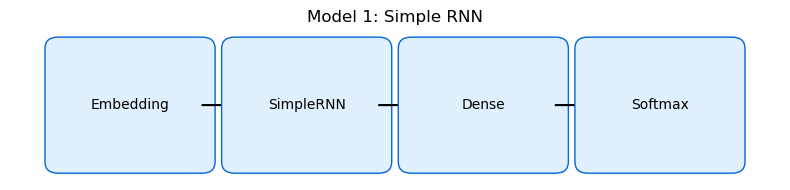

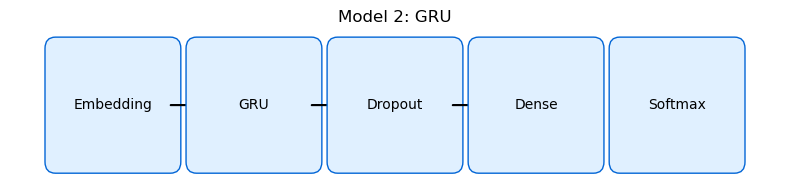

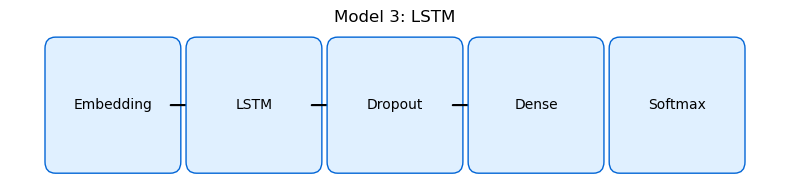

In [30]:

import matplotlib.patches as patches

def draw_architecture(blocks, title, filename):
    plt.figure(figsize=(8,2))
    ax = plt.gca(); ax.axis('off'); x = 0.05
    for label in blocks:
        rect = patches.FancyBboxPatch((x, 0.4), 0.22, 0.2, boxstyle='round,pad=0.02', fc='#e0f0ff', ec='#0366d6')
        ax.add_patch(rect); ax.text(x+0.11, 0.5, label, ha='center', va='center', fontsize=10)
        x += 0.27
        if x < 0.98: ax.arrow(x-0.05, 0.5, 0.04, 0, head_width=0.02, head_length=0.01, fc='k', ec='k')
    plt.title(title); plt.tight_layout(); plt.savefig(filename, dpi=150); plt.show()

_ = draw_architecture(['Embedding','SimpleRNN','Dense','Softmax'], 'Model 1: Simple RNN', 'arch_simple_rnn.png')
_ = draw_architecture(['Embedding','GRU','Dropout','Dense','Softmax'], 'Model 2: GRU', 'arch_gru.png')
_ = draw_architecture(['Embedding','LSTM','Dropout','Dense','Softmax'], 'Model 3: LSTM', 'arch_lstm.png')


## 8. Prepare padded sequences & labels (Variant B) and compare with Variant A
- Check shapes; confirm ~70/20/10 split and reasonable max_len.  
- Compare A vs B impact.


In [13]:

from sklearn.preprocessing import LabelEncoder

# Variant B inputs (used for modeling)
x_train = res_without['x_train']; x_val = res_without['x_val']; x_test = res_without['x_test']
max_len = res_without['metrics']['pad_max_len']
train_df_B = res_without['train_df']; val_df_B = res_without['val_df']; test_df_B = res_without['test_df']

# Variant A for comparison
x_train_A = res_with['x_train']; x_val_A = res_with['x_val']; x_test_A = res_with['x_test']
max_len_A = res_with['metrics']['pad_max_len']

# Label encoding across full dataset to keep ids stable
le = LabelEncoder(); le.fit(df[LABEL_COL])
y_train = le.transform(train_df_B[LABEL_COL]); y_val = le.transform(val_df_B[LABEL_COL]); y_test = le.transform(test_df_B[LABEL_COL])

num_classes = len(le.classes_)
print('Classes (label -> id):', {label:i for i,label in enumerate(le.classes_)})
print('Variant B shapes (train/val/test):', x_train.shape, x_val.shape, x_test.shape, '| max_len =', max_len)
print('Variant A shapes (train/val/test):', x_train_A.shape, x_val_A.shape, x_test_A.shape, '| max_len =', max_len_A)


Classes (label -> id): {'negative': 0, 'neutral': 1, 'positive': 2}
Variant B shapes (train/val/test): (10248, 27) (2929, 27) (1463, 27) | max_len = 27
Variant A shapes (train/val/test): (10248, 27) (2929, 27) (1463, 27) | max_len = 27


## 9. Class weights — why and how to read them
- Majority class gets weight < 1; minority classes > 1.  
- This helps macro-F1 and reduces majority bias.


In [14]:

from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print('Class weights (class_id -> weight):', class_weight_dict)
print('Class_id -> label:', {i: label for i, label in enumerate(le.classes_)})


Class weights (class_id -> weight): {0: 0.5316731517509727, 1: 1.5749193176579068, 2: 2.065296251511487}
Class_id -> label: {0: 'negative', 1: 'neutral', 2: 'positive'}


## 10.0. Implement and compare Deep Learning Architectures (SimpleRNN, GRU, LSTM) - Aim 3, 4, and 5
**Train & evaluate models — suppress Windows GPU notice & save artifacts**
- EarlyStopping with restore_best_weights.  
- Small hyperparameter sweep (units, dropout).  
- Save model comparison CSV + per-model loss curves and confusion matrices.


## These models were fitted again with strong regularization to avoide overfitting. See 10.1 again after followed by 11.1. At point 11.0 validation and loss curves were produced based on the original models fitted at point 10. At 11.1 validation and loss curves were produced again based on the models fitted at 10.1 that had strong regularization.

In [16]:
## # Hide a known non-actionable Windows message about GPU (TensorFlow >= 2.11)
warnings.filterwarnings("ignore", message=".*TensorFlow GPU support is not available on native Windows.*")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


# Try importing TensorFlow
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models, callbacks, optimizers
    HAS_TF = True
except Exception:
    HAS_TF = False
    print("TensorFlow not installed. Install with `pip install tensorflow`.")

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ===============================
# Experiment configuration
# ===============================
results   = []
histories = {}

EMBED_INPUT_DIM = len(variant_tok.word_index) + 1

UNITS_GRID   = [64, 128]
DROPOUT_GRID = [0.2, 0.4]      # Only used for GRU & LSTM
LR           = 1e-3
BATCH_SIZE  = 64
EPOCHS_MAX  = 20

# Early stopping (mandatory)
es = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# ===============================
# Model builder
# ===============================
def build_model(model_type: str, units: int, dropout: float):
    """
    Builds a sentiment classifier using:
    - SimpleRNN (baseline, no dropout)
    - GRU       (with dropout)
    - LSTM      (with dropout)
    """

    model = models.Sequential(name=model_type)

    # Embedding layer (Word2Vec initialised & fine-tuned)
    model.add(layers.Embedding(
        input_dim=EMBED_INPUT_DIM,
        output_dim=EMBEDDING_DIM,
        input_length=max_len,
        weights=[embedding_matrix],
        trainable=True
    ))

    if model_type == "SimpleRNN":
        model.add(layers.SimpleRNN(units))

    elif model_type == "GRU":
        model.add(layers.GRU(units))
        model.add(layers.Dropout(dropout))

    elif model_type == "LSTM":
        model.add(layers.LSTM(units))
        model.add(layers.Dropout(dropout))

    else:
        raise ValueError("Unknown model type")

    # Output layer
    model.add(layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# ===============================
# Training & hyperparameter tuning
# ===============================
if HAS_TF:

    for model_type in ["SimpleRNN", "GRU", "LSTM"]:

        best_val_loss = np.inf
        best_cfg      = None
        best_model    = None
        best_hist     = None

        start_time = time.time()

        dropout_values = [None] if model_type == "SimpleRNN" else DROPOUT_GRID

        for units in UNITS_GRID:
            for dr in dropout_values:

                model = build_model(
                    model_type=model_type,
                    units=units,
                    dropout=dr if dr is not None else 0.0
                )

                hist = model.fit(
                    x_train, y_train,
                    validation_data=(x_val, y_val),
                    epochs=EPOCHS_MAX,
                    batch_size=BATCH_SIZE,
                    class_weight=class_weight_dict,
                    callbacks=[es],
                    verbose=0
                )

                min_val = np.min(hist.history["val_loss"])

                if min_val < best_val_loss:
                    best_val_loss = min_val
                    best_cfg      = (units, dr)
                    best_model    = model
                    best_hist     = hist

        train_time = time.time() - start_time

        # ===============================
        # Evaluation on test set
        # ===============================
        y_pred = np.argmax(best_model.predict(x_test, verbose=0), axis=1)

        acc = accuracy_score(y_test, y_pred)

        precision_macro    = precision_score(y_test, y_pred, average="macro",    zero_division=0)
        precision_weighted = precision_score(y_test, y_pred, average="weighted", zero_division=0)

        recall_macro    = recall_score(y_test, y_pred, average="macro",    zero_division=0)
        recall_weighted = recall_score(y_test, y_pred, average="weighted", zero_division=0)

        f1_macro    = f1_score(y_test, y_pred, average="macro")
        f1_weighted = f1_score(y_test, y_pred, average="weighted")

        # Overfitting indicator (defined criterion)
        train_loss = best_hist.history["loss"][-1]
        val_loss   = best_hist.history["val_loss"][-1]
        overfit    = (val_loss - train_loss) > 0.15 * train_loss

        # Store results
        results.append({
            "Model": model_type,
            "Units": best_cfg[0],
            "Dropout": best_cfg[1],
            "Accuracy": acc,
            "Precision_macro": precision_macro,
            "Precision_weighted": precision_weighted,
            "Recall_macro": recall_macro,
            "Recall_weighted": recall_weighted,
            "F1_macro": f1_macro,
            "F1_weighted": f1_weighted,
            "Overfitting": overfit,
            "Train_Time_s": train_time,
            "Best_Val_Loss": best_val_loss
        })

        histories[model_type] = (
            best_hist,
            confusion_matrix(y_test, y_pred),
            classification_report(
                y_test,
                y_pred,
                target_names=list(le.classes_),
                output_dict=True
            )
        )

    # ===============================
    # Results table
    # ===============================
    results_df = pd.DataFrame(results)
    results_df["Dropout"] = results_df["Dropout"].astype("object")

    results_df = results_df[
        [
            "Model",
            "Units",
            "Dropout",
            "Accuracy",
            "Precision_macro",
            "Recall_macro",
            "F1_macro",
            "Precision_weighted",
            "Recall_weighted",
            "F1_weighted",
            "Overfitting",
            "Train_Time_s",
            "Best_Val_Loss"
        ]
    ]

    results_df.sort_values(by="F1_macro", ascending=False, inplace=True)
    display(results_df)

    results_df.to_csv("model_comparison_corrected.csv", index=False)
    print("✅ Saved: model_comparison_corrected.csv")

else:
    display(pd.DataFrame())


C:\Users\anwar\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
C:\Users\anwar\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
C:\Users\anwar\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


,Model,Units,Dropout,Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted,Overfitting,Train_Time_s,Best_Val_Loss
2,LSTM,64,0.4,0.801094,0.747696,0.748121,0.747902,0.801460,0.801094,0.801272,True,89.946313,0.517808
1,GRU,64,0.2,0.802461,0.750737,0.738995,0.742385,0.796498,0.802461,0.797769,True,93.531355,0.538113
0,SimpleRNN,128,NaN,0.751880,0.713805,0.711122,0.700342,0.789036,0.751880,0.761864,True,48.296489,0.643327


✅ Saved: model_comparison_corrected.csv


## 11. Save training vs validation loss curves & confusion matrices — interpretation (see the Validation and Loss curves again at 11.1 that is based on after strong regularization applied)
- Loss curves: if train loss decreases but val loss rises, overfitting.  
- Confusion matrix: where models confuse classes (e.g., neutral vs negative).  
- We save PNGs and per-model classification reports to `/reports`.


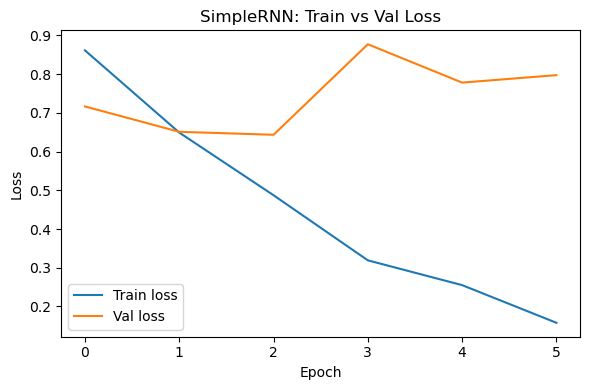

[Saved] reports\SimpleRNN_loss.png


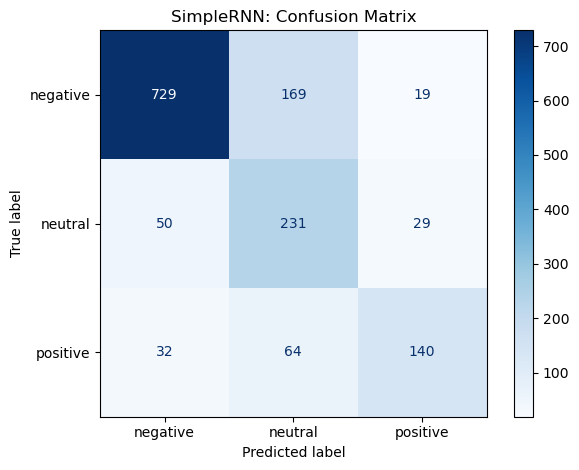

[Saved] reports\SimpleRNN_cm.png
[Saved] reports\SimpleRNN_classification_report.csv


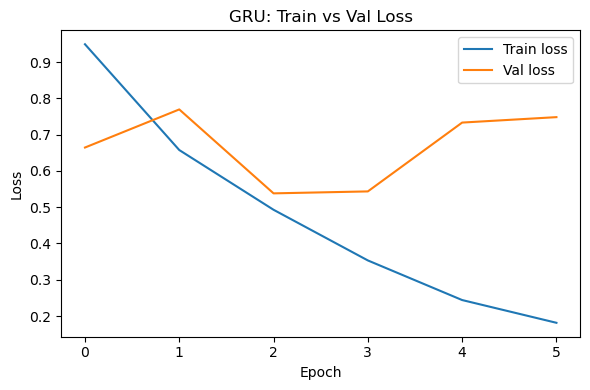

[Saved] reports\GRU_loss.png


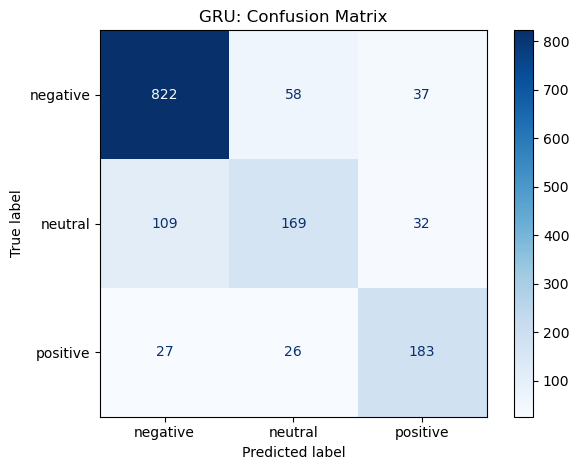

[Saved] reports\GRU_cm.png
[Saved] reports\GRU_classification_report.csv


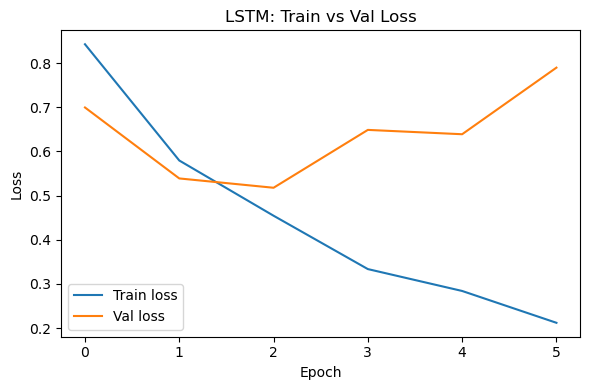

[Saved] reports\LSTM_loss.png


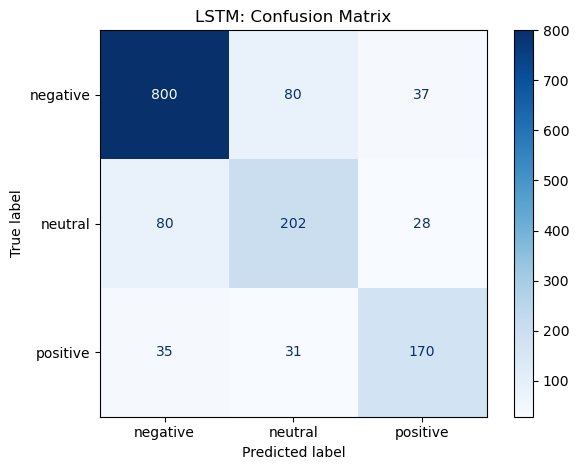

[Saved] reports\LSTM_cm.png
[Saved] reports\LSTM_classification_report.csv


In [17]:

from sklearn.metrics import ConfusionMatrixDisplay

if len(histories):
    for model_type, (hist, cm, report) in histories.items():
        # Loss curves
        plt.figure(figsize=(6,4))
        plt.plot(hist.history['loss'], label='Train loss')
        plt.plot(hist.history['val_loss'], label='Val loss')
        plt.title(f'{model_type}: Train vs Val Loss')
        plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.tight_layout()
        loss_path = os.path.join('reports', f'{model_type}_loss.png')
        plt.savefig(loss_path, dpi=150); plt.show(); print('[Saved]', loss_path)

        # Confusion matrix
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(le.classes_))
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f'{model_type}: Confusion Matrix'); plt.tight_layout()
        cm_path = os.path.join('reports', f'{model_type}_cm.png')
        plt.savefig(cm_path, dpi=150); plt.show(); print('[Saved]', cm_path)

        # Also save per-model classification report
        rep_df = pd.DataFrame(report).T
        rep_csv_path = os.path.join('reports', f'{model_type}_classification_report.csv')
        rep_df.to_csv(rep_csv_path); print('[Saved]', rep_csv_path)


## 10.1. Regularize training cells to reduce overfitting 

In [18]:
# ===========================
# Regularized training cell (drop-in replacement for v2 loop)
# Purpose: actively reduce overfitting
# ===========================

# ---------------------------
# Environment setup
# ---------------------------
# 1) Suppress a known Windows GPU warning (safe for CPU training)
warnings.filterwarnings(
    "ignore",
    message=".*TensorFlow GPU support is not available on native Windows.*"
)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.makedirs('reports', exist_ok=True)

# ---------------------------
# TensorFlow import
# ---------------------------
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
    HAS_TF = True
except Exception:
    HAS_TF = False
    print("TensorFlow not installed. Install with `pip install tensorflow`.")

# ---------------------------
# Sklearn metrics
# ---------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ---------------------------
# Containers
# ---------------------------
results   = []
histories = {}

# ---------------------------
# Hyperparameters (regularised)
# ---------------------------
# 2) Key knobs for overfitting mitigation
EMBED_INPUT_DIM = len(res_without['tokenizer'].word_index) + 1

# Smaller capacity + stronger regularization than v2
UNITS_GRID        = [48, 96] # ↓ capacity curbs variance
DROPOUT_GRID      = [0.3, 0.5] # ↑ dropout after recurrent layer
REC_DROPOUT_GRID  = [0.1, 0.2] # recurrent_dropout inside the RNN cell
L2_GRID           = [1e-5, 5e-5] # light L2 weight decay on kernels
SPATIAL_DROPOUTS  = [0.1, 0.2] # SpatialDropout1D over embeddings

LR = 1e-3
BATCH_SIZE = 64
EPOCHS_MAX = 30

# ---------------------------
# 3) Callbacks to attenuate overfitting:
#    - EarlyStopping (restores best weights)
#    - ReduceLROnPlateau (reduce LR when val loss stalls)
# ---------------------------
if HAS_TF:
    es = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    )
    rlrop = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=0
    )

# ---------------------------
# Model builder
# ---------------------------
def build_model(model_type, units, dropout, rec_dropout, l2_w, sdrop):
    """
    Build a regularized sequence classifier:
      Embedding (initialized from Word2Vec, trainable) 
      -> SpatialDropout1D(sdrop)
      -> {SimpleRNN|GRU|LSTM}(units, recurrent_dropout=rec_dropout, L2 on kernels)
      -> Dropout(dropout)
      -> Dense(num_classes, softmax, L2 on kernel)

    Why this works:
      - SpatialDropout1D decorrelates embedding features over time (better than element-wise Dropout for sequences).
      - recurrent_dropout regularizes state transitions inside the RNN cell.
      - L2 discourages overly large weights (simpler hypotheses).
      - Smaller units reduce variance.
    """
    reg = regularizers.l2(l2_w)

    model = models.Sequential(
        name=f"{model_type}_u{units}_do{dropout}_rdo{rec_dropout}_l2{l2_w}_sdo{sdrop}"
    )
    # Embedding initialized from Word2Vec; set trainable=True to fine-tune
    model.add(layers.Embedding(
        input_dim=EMBED_INPUT_DIM,
        output_dim=EMBEDDING_DIM,
        input_length=res_without['metrics']['pad_max_len'],
        weights=[embedding_matrix],
        trainable=True
    ))
    
    # Embed-level spatial dropout: drop entire features across timesteps
    model.add(layers.SpatialDropout1D(sdrop))
    
    # Recurrent backbone with recurrent_dropout and L2 on kernels
    if model_type == 'SimpleRNN':
        model.add(layers.SimpleRNN(
            units,
            recurrent_dropout=rec_dropout,
            kernel_regularizer=reg,
            recurrent_regularizer=reg
        ))
    elif model_type == 'GRU':
        model.add(layers.GRU(
            units,
            recurrent_dropout=rec_dropout,
            kernel_regularizer=reg,
            recurrent_regularizer=reg
        ))
    elif model_type == 'LSTM':
        model.add(layers.LSTM(
            units,
            recurrent_dropout=rec_dropout,
            kernel_regularizer=reg,
            recurrent_regularizer=reg
        ))
    else:
        raise ValueError("Unknown model type")

    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(
        num_classes,
        activation='softmax',
        kernel_regularizer=reg
    ))

    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=LR,
            clipnorm=1.0
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ===========================
# 4) Train with a compact grid; pick the best by min val_loss
# Training & Evaluation Loop    
# ===========================
if HAS_TF:

    for model_type in ['SimpleRNN', 'GRU', 'LSTM']:

        best = None
        best_hist = None
        start_total = time.time()

        for units in UNITS_GRID:
            for dr in DROPOUT_GRID:
                for rdo in REC_DROPOUT_GRID:
                    for l2w in L2_GRID:
                        for sdo in SPATIAL_DROPOUTS:

                            model = build_model(
                                model_type, units, dr, rdo, l2w, sdo
                            )

                            hist = model.fit(
                                x_train, y_train,
                                validation_data=(x_val, y_val),
                                batch_size=BATCH_SIZE,
                                epochs=EPOCHS_MAX,
                                class_weight=class_weight_dict,
                                callbacks=[es, rlrop],
                                verbose=0
                            )

                            val_min = float(np.min(hist.history['val_loss']))
                            if (best is None) or (val_min < best['best_val']):
                                best = {
                                    'cfg': (units, dr, rdo, l2w, sdo),
                                    'best_val': val_min,
                                    'model': model
                                }
                                best_hist = hist

        train_time = time.time() - start_total

        # ---------------------------
        # 5) Evaluate on the held-out test set (unchanged)
        # Test set evaluation
        # ---------------------------
        y_pred = np.argmax(
            best['model'].predict(x_test, verbose=0),
            axis=1
        )

        acc = accuracy_score(y_test, y_pred)

        precision_macro    = precision_score(
            y_test, y_pred, average='macro', zero_division=0
        )
        precision_weighted = precision_score(
            y_test, y_pred, average='weighted', zero_division=0
        )

        recall_macro    = recall_score(
            y_test, y_pred, average='macro', zero_division=0
        )
        recall_weighted = recall_score(
            y_test, y_pred, average='weighted', zero_division=0
        )

        f1_macro    = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')

        cm = confusion_matrix(y_test, y_pred)
        report = classification_report(
            y_test,
            y_pred,
            target_names=list(le.classes_),
            output_dict=True
        )

        # Keep (and show) the overfitting flag with a slightly stricter margin
        tr_loss = best_hist.history['loss'][-1]
        vl_loss = best_hist.history['val_loss'][-1]
        overfit_flag = (vl_loss - tr_loss) > 0.10 * max(1e-8, tr_loss)

        u, dr, rdo, l2w, sdo = best['cfg']

        results.append({
            'Model': model_type,
            'Units': u,
            'Dropout': dr,
            'Rec_Dropout': rdo,
            'L2': l2w,
            'SpatialDO': sdo,
            'Accuracy': acc,
            'Precision_macro': precision_macro,
            'Recall_macro': recall_macro,
            'F1_macro': f1_macro,
            'Precision_weighted': precision_weighted,
            'Recall_weighted': recall_weighted,
            'F1_weighted': f1_weighted,
            'Overfitting': overfit_flag,
            'Train_Time_s': train_time,
            'Best_Val_Loss': best['best_val']
        })

        histories[model_type] = (best_hist, cm, report)

    # ---------------------------
    # 6) Comparison table (still sorted by macro-F1)
    # Results table
    # ---------------------------
    results_df = pd.DataFrame(results)[[
        'Model', 'Units', 'Dropout', 'Rec_Dropout', 'L2', 'SpatialDO',
        'Accuracy',
        'Precision_macro', 'Recall_macro', 'F1_macro',
        'Precision_weighted', 'Recall_weighted', 'F1_weighted',
        'Overfitting', 'Train_Time_s', 'Best_Val_Loss'
    ]]

    results_df.sort_values(by='F1_macro', ascending=False, inplace=True)
    display(results_df)

    results_df.to_csv('model_comparison_regularised.csv', index=False)
    print("✅ Saved: model_comparison_regularised.csv")

else:
    display(pd.DataFrame())


C:\Users\anwar\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
C:\Users\anwar\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
C:\Users\anwar\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


,Model,Units,Dropout,Rec_Dropout,L2,SpatialDO,Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted,Overfitting,Train_Time_s,Best_Val_Loss
2,LSTM,96,0.3,0.1,0.00001,0.2,0.804511,0.750870,0.745218,0.747468,0.801473,0.804511,0.802593,True,975.046861,0.507253
1,GRU,96,0.3,0.1,0.00001,0.2,0.793575,0.749803,0.738315,0.740973,0.802392,0.793575,0.796233,True,1021.342232,0.511870
0,SimpleRNN,48,0.3,0.1,0.00001,0.1,0.792208,0.736579,0.725526,0.729920,0.786618,0.792208,0.788572,True,636.416014,0.623577


✅ Saved: model_comparison_regularised.csv


## 11.1 Save training vs validation loss curves & confusion matrices — interpretation (based on models after strong regularization applied)
- Loss curves: if train loss decreases but val loss rises, overfitting.  
- Confusion matrix: where models confuse classes (e.g., neutral vs negative).  
- We save PNGs and per-model classification reports to `/reports`.


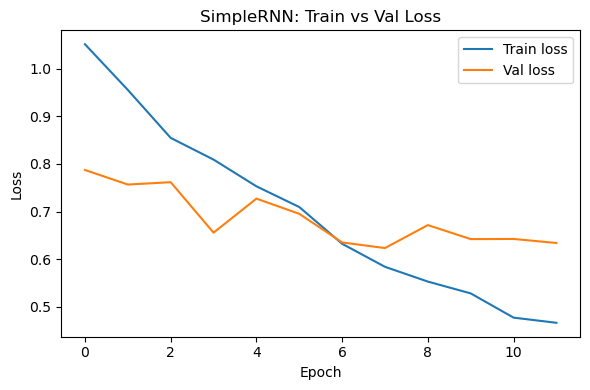

[Saved] reports\SimpleRNN_loss.png


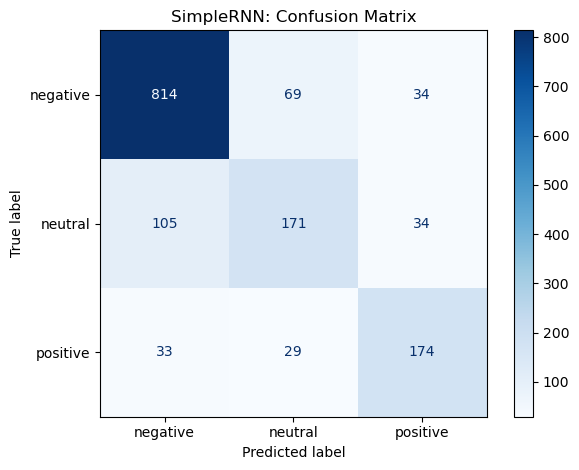

[Saved] reports\SimpleRNN_cm.png
[Saved] reports\SimpleRNN_classification_report.csv


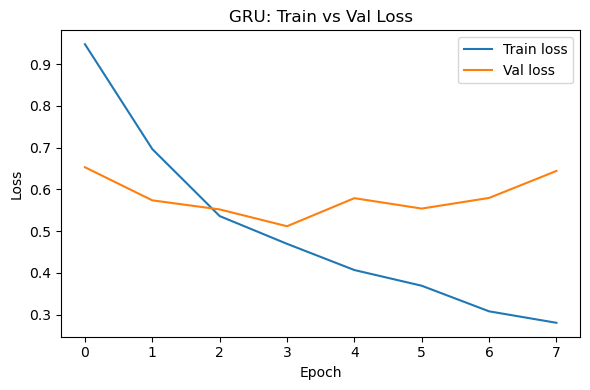

[Saved] reports\GRU_loss.png


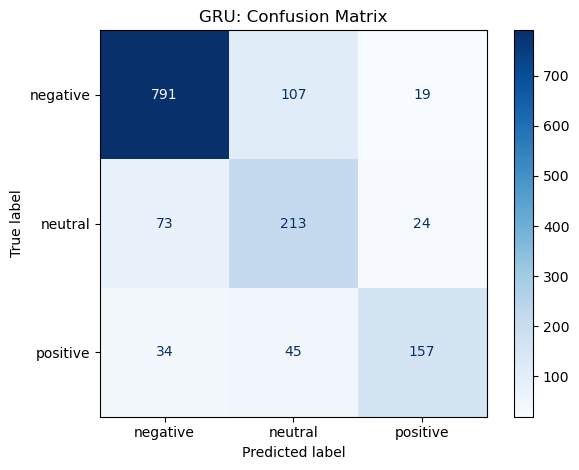

[Saved] reports\GRU_cm.png
[Saved] reports\GRU_classification_report.csv


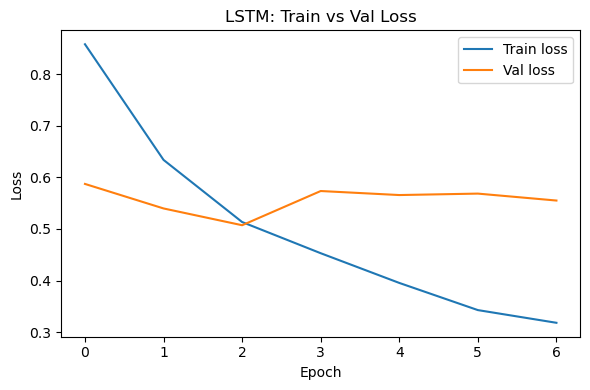

[Saved] reports\LSTM_loss.png


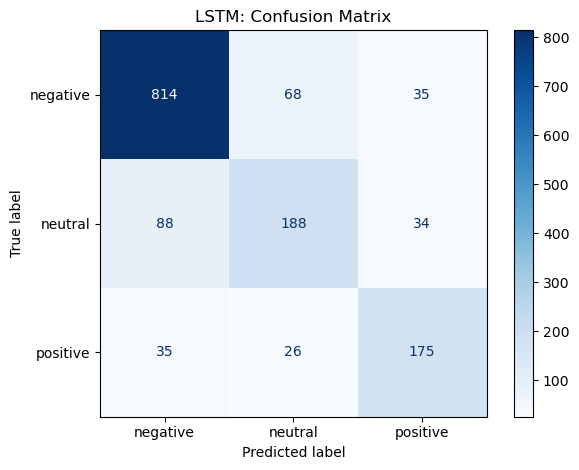

[Saved] reports\LSTM_cm.png
[Saved] reports\LSTM_classification_report.csv


In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

if len(histories):
    for model_type, (hist, cm, report) in histories.items():
        # Loss curves
        plt.figure(figsize=(6,4))
        plt.plot(hist.history['loss'], label='Train loss')
        plt.plot(hist.history['val_loss'], label='Val loss')
        plt.title(f'{model_type}: Train vs Val Loss')
        plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.tight_layout()
        loss_path = os.path.join('reports', f'{model_type}_loss.png')
        plt.savefig(loss_path, dpi=150); plt.show(); print('[Saved]', loss_path)

        # Confusion matrix
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(le.classes_))
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f'{model_type}: Confusion Matrix'); plt.tight_layout()
        cm_path = os.path.join('reports', f'{model_type}_cm.png')
        plt.savefig(cm_path, dpi=150); plt.show(); print('[Saved]', cm_path)

        # Also save per-model classification report
        rep_df = pd.DataFrame(report).T
        rep_csv_path = os.path.join('reports', f'{model_type}_classification_report.csv')
        rep_df.to_csv(rep_csv_path); print('[Saved]', rep_csv_path)


## 12. Compare architectures — summary table & guidance (Aim 5)
- Accuracy vs macro-F1 vs weighted-F1: use macro-F1 for balanced view across classes.  
- Overfitting flag: simple gap heuristic; inspect loss curves for confirmation.  
- Expect GRU to be faster; LSTM often best macro-F1; SimpleRNN as baseline.


In [20]:

if not results_df.empty:
    display(results_df)
else:
    print('Results table is empty (TensorFlow not installed or training was skipped).')


,Model,Units,Dropout,Rec_Dropout,L2,SpatialDO,Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_weighted,Recall_weighted,F1_weighted,Overfitting,Train_Time_s,Best_Val_Loss
2,LSTM,96,0.3,0.1,0.00001,0.2,0.804511,0.750870,0.745218,0.747468,0.801473,0.804511,0.802593,True,975.046861,0.507253
1,GRU,96,0.3,0.1,0.00001,0.2,0.793575,0.749803,0.738315,0.740973,0.802392,0.793575,0.796233,True,1021.342232,0.511870
0,SimpleRNN,48,0.3,0.1,0.00001,0.1,0.792208,0.736579,0.725526,0.729920,0.786618,0.792208,0.788572,True,636.416014,0.623577
